# Data Quality and Delay Targets

This notebook checks one merged airport-year dataset before interpreting delay patterns. It answers four basic questions:

- Does the file have the expected flight-level structure?
- Are important values missing or duplicated?
- How balanced are the two binary delay outcomes?
- How old are the ASPM and NOAA records matched to each flight?

Change `AIRPORT` and `YEAR` in `config.py` to reuse the same analysis for another merged dataset.

In [1]:
from pathlib import Path
import sys

EDA_DIR = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd() / "eda"
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import AIRPORT, FIGURE_DPI, RANDOM_STATE, SCATTER_SAMPLE_SIZE, TOP_CATEGORIES, YEAR
from eda_utils import (
    TARGET_COLUMNS,
    WEATHER_FLAGS,
    add_eda_columns,
    category_rate,
    load_merged,
    safe_sample,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = FIGURE_DPI
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

df = add_eda_columns(load_merged(AIRPORT, YEAR))
print(f"Loaded {AIRPORT}_{YEAR}: {len(df):,} flights and {df.shape[1]:,} columns after EDA helpers.")

Loaded JFK_2019: 124,759 flights and 70 columns after EDA helpers.


## Selected dataset

The table below confirms the selected airport and year, the number of rows and columns, and the date range. Each row should represent one scheduled flight departing from the selected airport.

In [2]:
dataset_overview = pd.DataFrame(
    {
        "Airport": [AIRPORT],
        "Year": [YEAR],
        "Flights": [len(df)],
        "Columns": [df.shape[1]],
        "First scheduled departure": [df["DATE"].min()],
        "Last scheduled departure": [df["DATE"].max()],
        "Unique airlines": [df["Reporting_Airline"].nunique()],
        "Unique destinations": [df["Dest"].nunique()],
    }
)
display(dataset_overview)
display(df.head())

,Airport,Year,Flights,Columns,First scheduled departure,Last scheduled departure,Unique airlines,Unique destinations
0,JFK,2019,124759,70,2019-01-01 05:00:00,2019-12-31 23:58:00,10,71


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,TaxiOut,WheelsOff,CRSArrTime,ArrDel15,ArrivalDelayGroups,CRSElapsedTime,Distance,DistanceGroup,DATE,ASPM_LOOKUP_DATE,ASPM_Airport,ASPM_ReportDate,ASPM_Hour,ASPM_Scheduled_Departures,ASPM_Scheduled_Arrivals,ASPM_Average_Taxi_Out_Time,ASPM_Average_Taxi_Out_Delay,ASPM_Average_Airborne_Delay,ASPM_Average_Taxi_In_Delay,ASPM_DATE,ASPM_AGE_MINUTES,NOAA_DATE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,Rain,Drizzle,Snow,Fog,Mist,Thunderstorm,FreezingPrecip,Showers,PrecipOccurred,WindX,WindY,NOAA_AGE_MINUTES,ScheduledDepartureHour,ScheduledDepartureMonth,MonthName,DayName,TimeOfDay,ASPM_Total_Scheduled_Traffic,WeatherConditionCount,AdverseWeather,VisibilityCategory,DepDel15_Label,ArrDel15_Label
0,2019,1,1,1,2,2019-01-01,B6,N635JB,939,JFK,NY,BQN,PR,500,454.000,-6.000,0.000,0.000,-1.000,14.000,508.000,943,0.000,-2.000,223.000,"1,576.000",7,2019-01-01 05:00:00,2019-01-01 04:00:00,JFK,2019-01-01,4,0,4,0.000,0.000,5.000,3.130,2019-01-01 04:00:00,60.000,2019-01-01 04:51:00,55.000,55.000,0.000,100.000,6.000,22.000,0,0,0,0,1,0,0,0,0,20.673,7.524,9.000,5,1,Jan,Tue,Morning,4,1,1,Moderate (5–8),On time,On time
1,2019,1,1,1,2,2019-01-01,B6,N998JB,1083,JFK,NY,MCO,FL,500,549.000,49.000,49.000,1.000,3.000,16.000,605.000,746,1.000,3.000,166.000,944.000,4,2019-01-01 05:00:00,2019-01-01 04:00:00,JFK,2019-01-01,4,0,4,0.000,0.000,5.000,3.130,2019-01-01 04:00:00,60.000,2019-01-01 04:51:00,55.000,55.000,0.000,100.000,6.000,22.000,0,0,0,0,1,0,0,0,0,20.673,7.524,9.000,5,1,Jan,Tue,Morning,4,1,1,Moderate (5–8),Delayed 15+ min,Delayed 15+ min
2,2019,1,1,1,2,2019-01-01,B6,N913JB,2201,JFK,NY,FLL,FL,500,517.000,17.000,17.000,1.000,1.000,12.000,529.000,805,0.000,0.000,185.000,"1,069.000",5,2019-01-01 05:00:00,2019-01-01 04:00:00,JFK,2019-01-01,4,0,4,0.000,0.000,5.000,3.130,2019-01-01 04:00:00,60.000,2019-01-01 04:51:00,55.000,55.000,0.000,100.000,6.000,22.000,0,0,0,0,1,0,0,0,0,20.673,7.524,9.000,5,1,Jan,Tue,Morning,4,1,1,Moderate (5–8),Delayed 15+ min,On time
3,2019,1,1,1,2,2019-01-01,B6,N995JB,1403,JFK,NY,SJU,PR,540,534.000,-6.000,0.000,0.000,-1.000,17.000,551.000,1027,0.000,-2.000,227.000,"1,598.000",7,2019-01-01 05:40:00,2019-01-01 04:00:00,JFK,2019-01-01,4,0,4,0.000,0.000,5.000,3.130,2019-01-01 04:00:00,100.000,2019-01-01 04:51:00,55.000,55.000,0.000,100.000,6.000,22.000,0,0,0,0,1,0,0,0,0,20.673,7.524,49.000,5,1,Jan,Tue,Morning,4,1,1,Moderate (5–8),On time,On time
4,2019,1,1,1,2,2019-01-01,B6,N991JB,23,JFK,NY,LAX,CA,545,605.000,20.000,20.000,1.000,1.000,23.000,628.000,909,1.000,1.000,384.000,"2,475.000",10,2019-01-01 05:45:00,2019-01-01 04:00:00,JFK,2019-01-01,4,0,4,0.000,0.000,5.000,3.130,2019-01-01 04:00:00,105.000,2019-01-01 04:51:00,55.000,55.000,0.000,100.000,6.000,22.000,0,0,0,0,1,0,0,0,0,20.673,7.524,54.000,5,1,Jan,Tue,Morning,4,1,1,Moderate (5–8),Delayed 15+ min,Delayed 15+ min


## Column structure

This summary shows each column's data type, number of populated values, missing values, and number of distinct values. It is a compact way to spot type problems, unexpected empty fields, and columns that may be constant.

In [3]:
column_summary = pd.DataFrame(
    {
        "DataType": df.dtypes.astype(str),
        "NonNull": df.notna().sum(),
        "Missing": df.isna().sum(),
        "MissingPercent": df.isna().mean().mul(100),
        "UniqueValues": df.nunique(dropna=True),
    }
).sort_values(["MissingPercent", "UniqueValues"], ascending=[False, True])

display(column_summary)

,DataType,NonNull,Missing,MissingPercent,UniqueValues
Year,int64,124759,0,0.000,1
Origin,object,124759,0,0.000,1
OriginState,object,124759,0,0.000,1
ASPM_Airport,object,124759,0,0.000,1
Showers,int64,124759,0,0.000,1
...,...,...,...,...,...
Tail_Number,object,124759,0,0.000,2520
ASPM_LOOKUP_DATE,datetime64[ns],124759,0,0.000,6932
ASPM_DATE,datetime64[ns],124759,0,0.000,6932
NOAA_DATE,datetime64[ns],124759,0,0.000,10063


## Missing values

The chart focuses on columns with missing values. A blank result means the selected merged dataset has no missing values. Missingness should still be checked for every airport and year because source coverage can differ.

In [4]:
missing = (
    column_summary.loc[column_summary["Missing"] > 0, ["Missing", "MissingPercent"]]
    .sort_values("MissingPercent", ascending=False)
)

if missing.empty:
    print("No missing values were found in this dataset.")
else:
    display(missing)
    plot_data = missing.reset_index(names="Column")
    plt.figure(figsize=(10, max(4, 0.35 * len(plot_data))))
    sns.barplot(data=plot_data, x="MissingPercent", y="Column", color="#4C72B0")
    plt.title(f"Missing values — {AIRPORT} {YEAR}")
    plt.xlabel("Missing rows (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

No missing values were found in this dataset.


## Duplicate checks

The first check looks for rows that are identical across every column. The second uses a practical flight identifier made from the scheduled date, airline, flight number, origin, and destination. A repeated practical key is not automatically an error, but it should be reviewed.

In [5]:
flight_key = [
    "DATE",
    "Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Origin",
    "Dest",
]

duplicate_summary = pd.DataFrame(
    {
        "Check": ["Exact duplicate rows", "Repeated practical flight key"],
        "Rows": [
            int(df.duplicated().sum()),
            int(df.duplicated(subset=flight_key, keep=False).sum()),
        ],
    }
)
duplicate_summary["PercentOfFlights"] = duplicate_summary["Rows"].div(len(df)).mul(100)
display(duplicate_summary)

repeated_keys = df.loc[df.duplicated(subset=flight_key, keep=False), flight_key]
if not repeated_keys.empty:
    display(repeated_keys.sort_values(flight_key).head(20))

,Check,Rows,PercentOfFlights
0,Exact duplicate rows,0,0.000
1,Repeated practical flight key,0,0.000


## Target balance

`DepDel15` and `ArrDel15` are the two outcomes used by the three planned models. These charts show the share of on-time and delayed flights. Large differences between the classes will affect how model accuracy is interpreted later.

,Target,Status,Flights,Percent
0,DepDel15,On time,101213,81.127
1,DepDel15,Delayed 15+ min,23546,18.873
2,ArrDel15,On time,99598,79.832
3,ArrDel15,Delayed 15+ min,25161,20.168


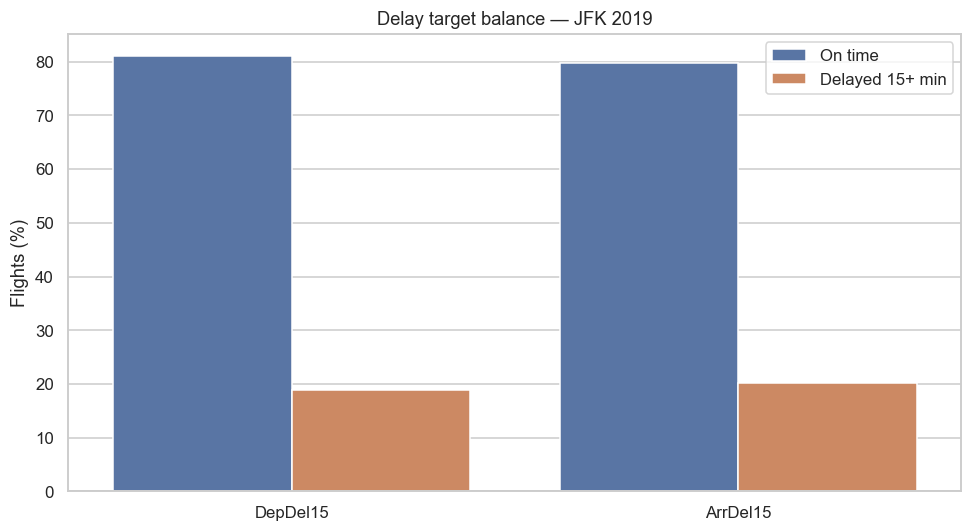

In [6]:
target_summary = []
for target in TARGET_COLUMNS:
    counts = df[target].value_counts(dropna=False).sort_index()
    for value, count in counts.items():
        status = "Missing" if pd.isna(value) else ("Delayed 15+ min" if value == 1 else "On time")
        target_summary.append(
            {
                "Target": target,
                "Status": status,
                "Flights": count,
                "Percent": count / len(df) * 100,
            }
        )

target_summary = pd.DataFrame(target_summary)
display(target_summary)

plt.figure(figsize=(9, 5))
sns.barplot(data=target_summary, x="Target", y="Percent", hue="Status")
plt.title(f"Delay target balance — {AIRPORT} {YEAR}")
plt.xlabel("")
plt.ylabel("Flights (%)")
plt.legend(title="")
plt.tight_layout()
plt.show()

## Flight volume over the year

Daily flight counts help reveal gaps, unusual drops, or seasonal changes in the source data. The seven-day average makes the broader pattern easier to see.

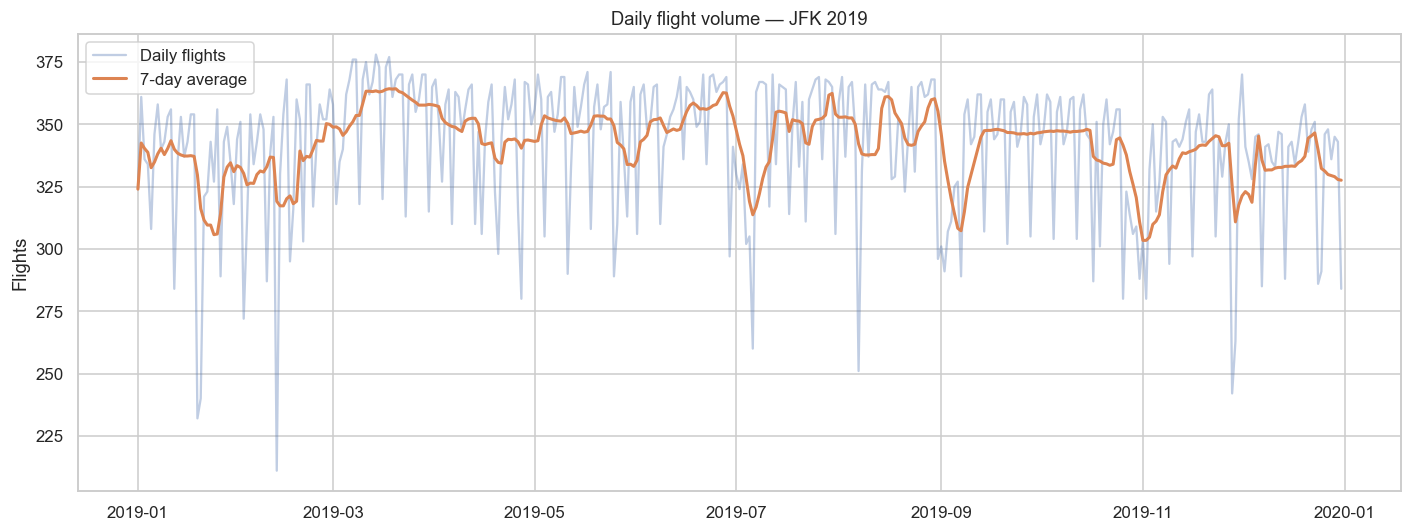

In [7]:
daily_volume = (
    df.set_index("DATE")
    .resample("D")
    .size()
    .rename("Flights")
    .to_frame()
)
daily_volume["SevenDayAverage"] = daily_volume["Flights"].rolling(7, min_periods=1).mean()

plt.figure(figsize=(13, 5))
sns.lineplot(data=daily_volume, x=daily_volume.index, y="Flights", alpha=0.35, label="Daily flights")
sns.lineplot(data=daily_volume, x=daily_volume.index, y="SevenDayAverage", linewidth=2, label="7-day average")
plt.title(f"Daily flight volume — {AIRPORT} {YEAR}")
plt.xlabel("")
plt.ylabel("Flights")
plt.legend()
plt.tight_layout()
plt.show()

## Age of matched source records

`ASPM_AGE_MINUTES` and `NOAA_AGE_MINUTES` measure how far each matched source record is from the flight's scheduled departure. The merge is designed to use earlier information, so negative ages would require investigation. Very old matches may also be less useful.

,count,mean,std,min,1%,5%,50%,95%,99%,max,NegativeRows
ASPM_AGE_MINUTES,"124,759.000",88.897,18.877,60.000,60.000,60.000,90.000,119.000,119.000,119.000,0
NOAA_AGE_MINUTES,"124,759.000",24.426,16.846,0.000,0.000,0.000,24.000,53.000,59.000,59.000,0


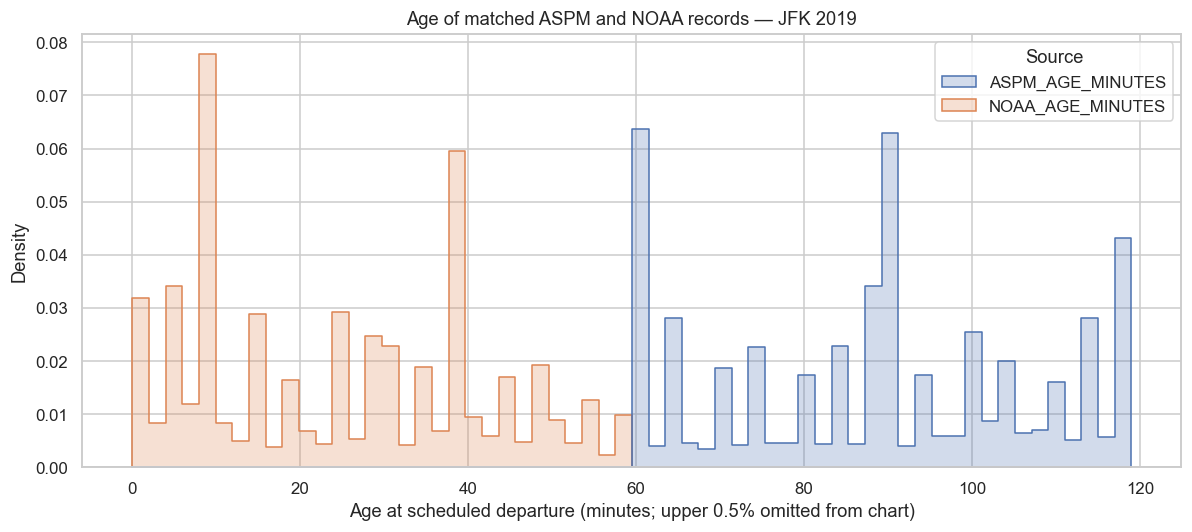

In [8]:
age_columns = ["ASPM_AGE_MINUTES", "NOAA_AGE_MINUTES"]
age_summary = df[age_columns].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
age_summary["NegativeRows"] = (df[age_columns] < 0).sum()
display(age_summary)

age_long = df[age_columns].melt(var_name="Source", value_name="AgeMinutes")
upper_age = age_long["AgeMinutes"].quantile(0.995)
plot_age = age_long.loc[age_long["AgeMinutes"] <= upper_age]

plt.figure(figsize=(11, 5))
sns.histplot(
    data=plot_age,
    x="AgeMinutes",
    hue="Source",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title(f"Age of matched ASPM and NOAA records — {AIRPORT} {YEAR}")
plt.xlabel("Age at scheduled departure (minutes; upper 0.5% omitted from chart)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## Initial review checklist

Before moving on, record any findings that could affect later analysis:

- unexpected missing or duplicate rows;
- gaps or abrupt changes in daily flight volume;
- highly uneven delay classes;
- negative or unusually old ASPM or NOAA matches;
- constant columns that add no information.

These checks describe data quality. They do not decide which columns are allowed in each model; that information boundary is enforced later when the model datasets are created.